# 1.&nbsp;Đại lượng thống kê

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use(['seaborn-v0_8', 'seaborn-v0_8-whitegrid'])
%config InlineBackend.figure_format = 'retina'

### Trung bình
Xét biến ngẫu nhiên $x$ có thể nhận $N$ giá trị $x_1, x_2,\dots,x_N$ với xác suất xuất hiện lần lượt là $p_1,p_2,\dots,p_N$. Mean (trung bình) của $x$ được tính theo 2 công thức như sau:

$$\mu_x=\sum_{n=1}^{N} x_np_n = \frac{x_1+x_2+\dots+x_n}{N}$$

Ứng dụng:
- Xác định lợi nhuận, doanh thu kỳ vọng của một dự án kinh doanh
- Ước lượng lợi nhuận của các khoản đầu tư

♈ **Case Study 1**

Một công ty sản suất bóng đèn điện. Tỷ lệ lỗi của mỗi lô là 1/50. Tuy nhiên, công ty sẽ không biết cái nào bị lỗi đến khi nhận được phản hồi của khách hàng về sản phẩm lỗi đó. Với mỗi bóng đèn thông thường, công ty lãi 30 USD nhưng với mỗi sản phẩm hỏng, công ty phải đền 800 USD. Công ty này có lãi trong dài hạn hay không?

In [ ]:
mean_profit = 30*49/50 -800*1/50
print(f'Mean profit = {mean_profit:.2f}')

Mean profit = 13.40


### Trung vị
Median (trung vị) là giá trị ở vị trí chính giữa tập dữ liệu, chia tập dữ liệu thành 2 phần bằng nhau, mỗi phần chứa 50% số quan sát.

In [ ]:
np.random.seed(1)
sample = np.random.randint(100, 1000, size=100)
sample

array([137, 335, 172, 867, 815, 745, 947, 244, 229, 683, 849, 608, 490,
       381, 278, 376, 354, 457, 568, 352, 590, 768, 498, 662, 680, 315,
       853, 603, 578, 964, 186, 241, 493, 107, 419, 929, 634, 413, 613,
       996, 416, 309, 364, 828, 753, 727, 531, 733, 556, 642, 171, 487,
       554, 661, 413, 615, 892, 597, 143, 688, 126, 920, 436, 721, 983,
       397, 566, 115, 164, 296, 125, 467, 838, 571, 382, 765, 716, 122,
       877, 807, 226, 379, 481, 456, 255, 413, 695, 266, 748, 388, 518,
       878, 379, 755, 851, 187, 893, 343, 448, 686])

In [ ]:
np.median(sample)

524.5

♈ **Case Study 3**

Dữ liệu về số lượng sản phẩm bán ra trong 20 ngày của 2 mặt hàng A và B được cho trong dataframe dưới đây. Tính trung bình và trung vị của số lượng mỗi sản phẩm và đưa ra đánh giá về 2 sản phẩm.


In [ ]:
df = pd.DataFrame({
    'A': [26,37,30,30,28,22,25,27,29,31,36,30,28,29,37,30,32,35,39],
    'B': [19,12,15,18,21,17,15,22,21,18,19,17,12,11,10,29,12,200,100]}
)
df.head()

,A,B
0,26,19
1,37,12
2,30,15
3,30,18
4,28,21


In [ ]:
df['A'].mean()

30.57894736842105

In [ ]:
df['B'].mean()

30.94736842105263

In [ ]:
df['A'].median()

30.0

In [ ]:
df['B'].median()

18.0

Nhận xét: Tuy mean bằng nhau nhưng median của B thấp hơn. Lý do là vì biến B có 2 ngày lớn hơn hẳn phần còn lại, kéo trung bình cao lên. Nếu không có 2 giá trị outlier này thì những ngày còn lại không cao đến như vậy. Như vậy kết luận:
- Số lượng SP A cao hơn B
- Median không bị ảnh hưởng bởi outlier

### Tứ phân vị
Quartiles (tứ phân vị) là bộ 3 giá trị $Q_1,Q_2,Q_3$ chia tập dữ liệu thành 4 phần có số bản ghi bằng nhau, mỗi phần chứa 25% kích thước dữ liệu.

<br>
<center>
<img src="https://cdn.scribbr.com/wp-content/uploads/2022/05/Quartiles-probability-distribution.webp" width=600px;>
</center>

*Nguồn: https://www.scribbr.com/statistics/quartiles-quantiles/*

Ý nghĩa:
- Có 25% số quan sát nhỏ hơn $Q_1$
- Có 50% số quan sát nhỏ hơn $Q_2$ (median)
- Có 75% số quan sát nhỏ hơn $Q_3$

Nếu thay 25%, 50%, 75% bằng bất cứ giá trị nào khác thì thu được quantile - là khái niệm khái quát hơn quartiles. Ký hiệu: $x_{0.6}$ là quantile 60% hoặc quantile 0.6 của biến $x$. Có 60% số quan sát của $x$ nhỏ hơn $x_{0.6}$.


<br>
<center>
<img src="https://api.www.labxchange.org/api/v1/xblocks/lb:LabXchange:d8863c77:html:1/storage/211626365402575-b88c4d0fdacd5abb4c3dc2de3bc004bb.png" width=600px;>
</center>

*Nguồn: https://www.labxchange.org/library/items/lb:LabXchange:d8863c77:html:1*


In [ ]:
np.quantile(sample, [0.25, 0.5, 0.75])

array([353.5, 524.5, 728.5])

In [ ]:
# unpacking quartiles
q1, q2, q3 = np.quantile(sample, [0.25, 0.5, 0.75])

♈ **Case Study 4**

- Tính tứ phân vị của các trường dữ liệu trong tập dữ liệu `youtube_trending`.
- Tính các phân vị thứ 10%, 30%, 60%, 70%, 90%, 99% của các trường: views, likes và đưa ra nhận xét về phân bố của tập dữ liệu.

In [ ]:
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")

In [ ]:
dfYoutube['views'].quantile([0.25,0.5,0.75])

0.25      89609.0
0.50     311621.0
0.75    1001367.0
Name: views, dtype: float64

### Phương sai
Variance là trung bình chênh lệch giữa các điểm dữ liệu với giá trị trung bình của các điểm dữ liệu đó. Phương sai thể hiện sự sai lệch của dữ liệu so với giá trị trung bình, phương sai càng lớn có nghĩa có càng nhiều giá trị cách xa giá trị trung bình

$$\sigma^2 = \frac{1}{N}\sum_{n=1}^N{(x_n - \mu)}^2$$

<br>
<center>
<img src="https://cdn.kastatic.org/ka-perseus-graphie/402a10abd400eff81a8da2dfaee932e657dbd6f0.svg" width=400px;>
</center>

*Nguồn: https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/variance-standard-deviation-population/a/introduction-to-standard-deviation*

<br>
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f9/Comparison_standard_deviations.svg/1200px-Comparison_standard_deviations.svg.png" width=600px;>
</center>

*Nguồn: https://en.wikipedia.org/wiki/Standard_deviation*

♈ **Coding Session 5**

Tính phương sai và độ lệch chuẩn các trường dữ liệu trong tập dữ liệu `youtube_trending`.

In [ ]:
import pandas as pd
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")

In [ ]:
dfYoutube[['views','likes','dislikes','comment_count']].var()

views            2.611371e+13
likes            2.907475e+10
dislikes         1.512594e+09
comment_count    9.378826e+08
dtype: float64

In [ ]:
dfYoutube[['views','likes','dislikes','comment_count']].std()

views            5.110157e+06
likes            1.705132e+05
dislikes         3.889208e+04
comment_count    3.062487e+04
dtype: float64

**Thảo luận**: Tại sao có phương sai vẫn cần có độ lệch chuẩn?



Vì độ lệch chuẩn có đơn vị bằng đơn vị của đại lượng đang xét còn phương sai bằng độ lệch chuẩn bình phương nên không phản ánh đúng độ lệch theo đơn vị đó.

### Hệ số tương quan
Hệ số tương quan là một chỉ số thống kê phản ánh mối quan hệ tuyến tính giữa các biến, hệ số tương quan dương/âm càng gần 1 có nghĩa hai biến đó có tương quan càng mạnh, nếu hệ số tương quan gần 0 thì hai biến không có tương quan với nhau.

Hệ số tương quan là 1 hệ số quan trọng để đánh giá mối quan hệ giữa các biến, đặc biệt là dể lựa chọn các features cho các mô hình học máy - Nếu các feature có tương quan quá thấp với biến phụ thuộc thì có thể xem xét bỏ ra khỏi mô hình

$$\rho_{xy} = \frac{\text{Cov}(x,y)}{\sigma_x\sigma_y}$$

<br>
<center>
<img src="https://ars.els-cdn.com/content/image/3-s2.0-B9780128013632000097-f09-09-9780128013632.jpg" width=500px;>
</center>

*Nguồn: https://www.sciencedirect.com/topics/physics-and-astronomy/correlation-coefficient*

♈ **Coding Session 6:** Tính hệ số tương quan giữa trường `likes` và `comment_count` trong tập dữ liệu `youtube_trending`

In [ ]:
dfYoutube[['likes','comment_count']].corr()

,likes,comment_count
likes,1.000000,0.850243
comment_count,0.850243,1.000000


# 2.&nbsp;Biểu đồ thống kê

Biểu đồ thống kê không tập trung vào biểu diễn các chiều dữ liệu như các biểu đồ thông thường, nhưng chúng giúp DA/DS hiểu một cách nhanh và sâu sắc nhất về dữ liệu. Các biểu đồ thống kê thường yêu cầu người dùng có hiểu biết sâu về các chỉ số thống kê để có thể hiểu và áp dụng trong phân tích dữ liệu.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use(['seaborn-v0_8', 'seaborn-v0_8-whitegrid'])
%config InlineBackend.figure_format = 'retina'

## 2.1. Bar chart

Bar chart (biểu đồ cột) là loại biểu đồ phổ biến dùng để so sánh giá trị của từng phân khúc. Bar chart thể hiện được 3 chiều thông tin:
- **Trục x:** thuộc tính Category
- **Trục y:** thuộc tính Value
- **Màu sắc:** thuộc tính Category

In [ ]:
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")
dfYoutube.head()

,video_id,trending_date,channel_title,category_id,publish_time,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
0,2kyS6SvSYSE,11/14/2017,CaseyNeistat,22,2017-11-13T17:13:01.000Z,748374,57527,2966,15954,False,False,People & Blogs
1,1ZAPwfrtAFY,11/14/2017,LastWeekTonight,24,2017-11-13T07:30:00.000Z,2418783,97185,6146,12703,False,False,Entertainment
2,5qpjK5DgCt4,11/14/2017,Rudy Mancuso,23,2017-11-12T19:05:24.000Z,3191434,146033,5339,8181,False,False,Comedy
3,puqaWrEC7tY,11/14/2017,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,343168,10172,666,2146,False,False,Entertainment
4,d380meD0W0M,11/14/2017,nigahiga,24,2017-11-12T18:01:41.000Z,2095731,132235,1989,17518,False,False,Entertainment


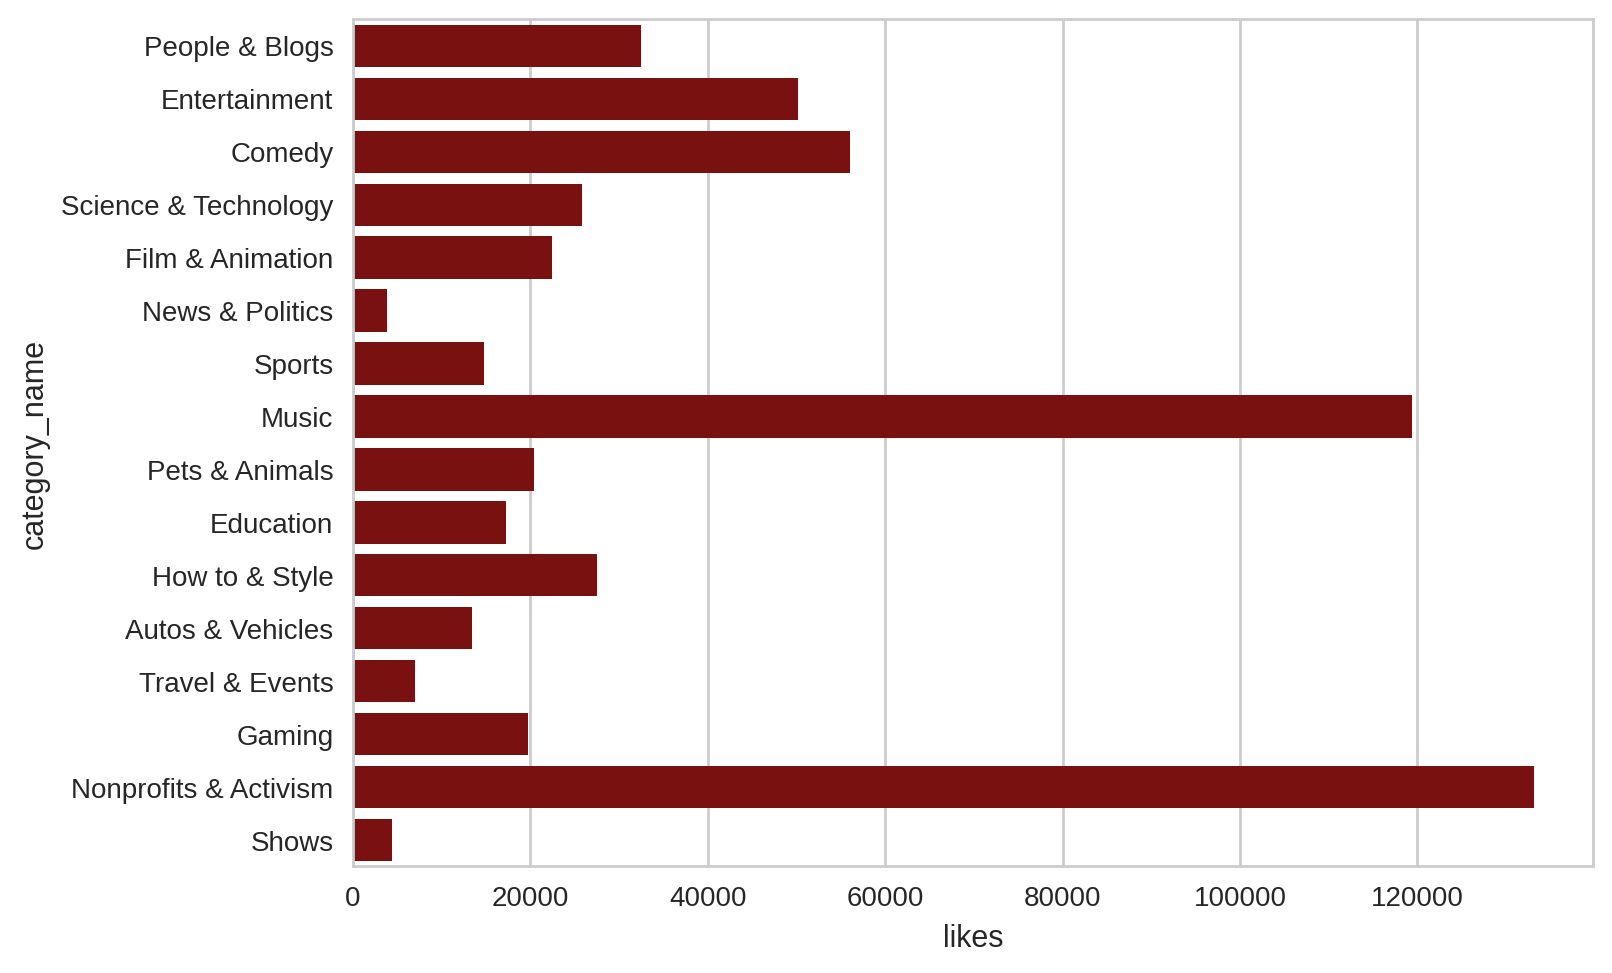

In [ ]:
sns.barplot(x='likes', y='category_name', data=dfYoutube, color='darkred', errorbar=None)
plt.show()

♈ **Case study 7**

Vẽ biểu đồ cột so sánh lượng views giữa 2 thể loại: Entertainment và Comedy. Trong đó thể hiện thêm lượng views của những video bị tắt comment của mỗi thể loại.

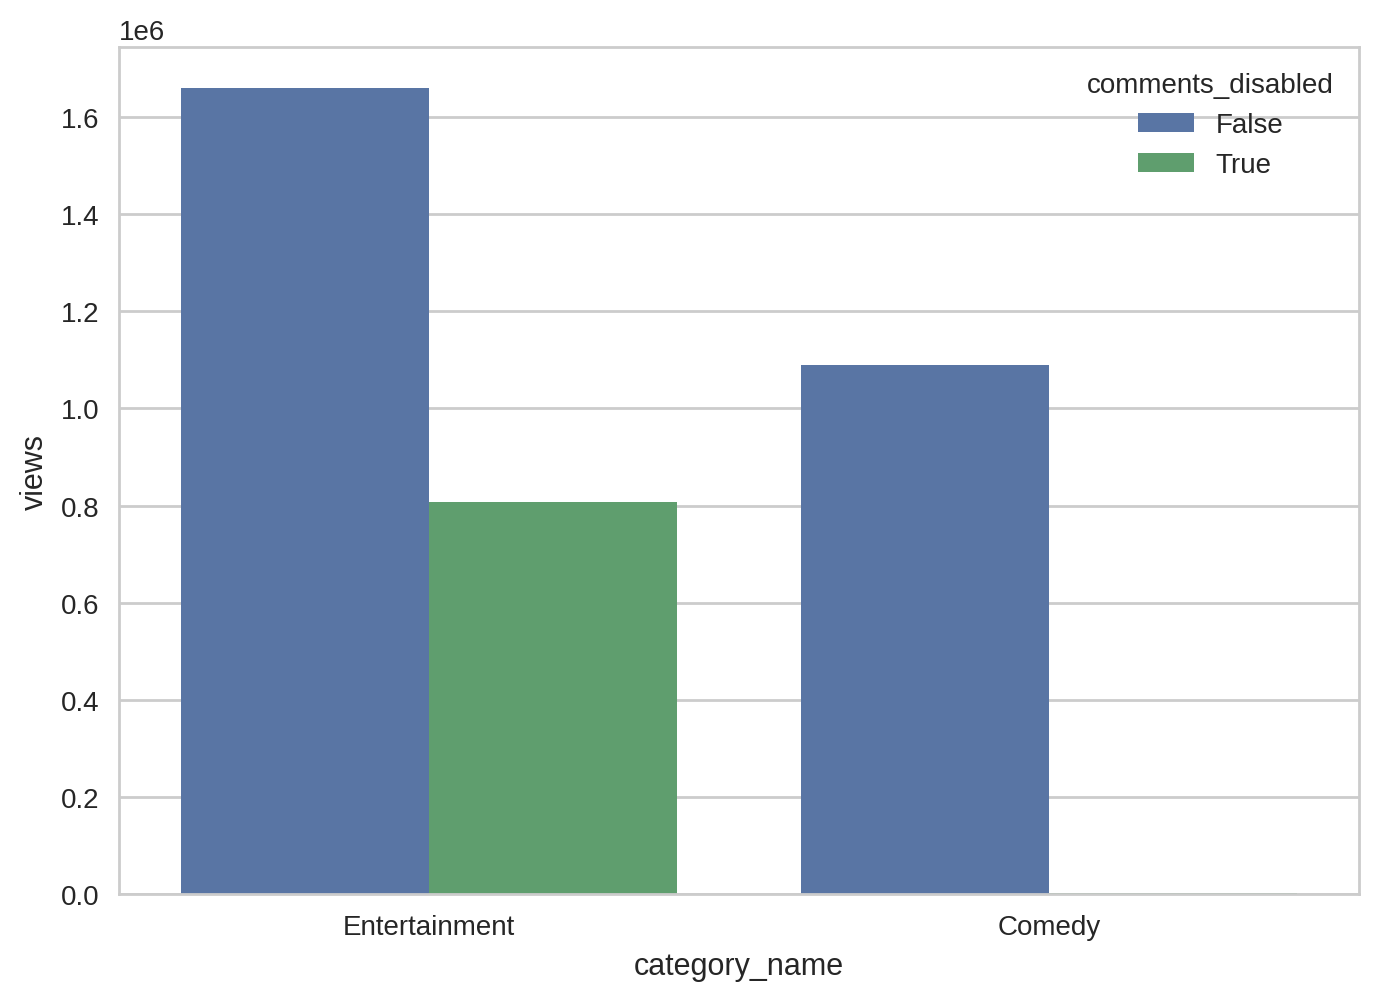

In [ ]:
dfFilter = dfYoutube[dfYoutube['category_name'].isin(['Entertainment','Comedy'])]
sns.barplot(x='category_name', y='views', hue='comments_disabled', data=dfFilter, errorbar=None)
plt.show()

## 2.2. Heat Map
[Heat Maps](https://en.wikipedia.org/wiki/Heat_map) làm rõ các giá trị cao/thâp, âm/dương. Mặc dù heat map khá đơn giản nhưng chúng rất hữu ích khi đi kèm với các bảng biểu thống kê như *correlation matrix (ma trận hệ số tương quan)* hay *pivot table*.

Khi vẽ heat map cần lưu ý đến độ dao động của dữ liệu để chọn dải màu hợp lí. Ví dụ với các giá trị liên tục dương thì nên chọn *sequential palette* - dải màu liên tục từ nhạt tới đậm, còn với các giá trị có cả âm và dương nên chọn *diverging palette* - dải màu đối lập thể hiện rõ giá trị âm/dương


In [ ]:
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")
dfYoutube.head()

,video_id,trending_date,channel_title,category_id,publish_time,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
0,2kyS6SvSYSE,11/14/2017,CaseyNeistat,22,2017-11-13T17:13:01.000Z,748374,57527,2966,15954,False,False,People & Blogs
1,1ZAPwfrtAFY,11/14/2017,LastWeekTonight,24,2017-11-13T07:30:00.000Z,2418783,97185,6146,12703,False,False,Entertainment
2,5qpjK5DgCt4,11/14/2017,Rudy Mancuso,23,2017-11-12T19:05:24.000Z,3191434,146033,5339,8181,False,False,Comedy
3,puqaWrEC7tY,11/14/2017,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,343168,10172,666,2146,False,False,Entertainment
4,d380meD0W0M,11/14/2017,nigahiga,24,2017-11-12T18:01:41.000Z,2095731,132235,1989,17518,False,False,Entertainment


### Correlation matrix
Hệ số tương quan của mỗi cặp biến $x,y$ được tính như sau:

$$
\rho_{\mathbf{x},\mathbf{y}} =
\frac{1}{N} \sum_{n=1}^{N}{\frac{(x_n-\mu_{\mathbf{x}})(y_n-\mu_{\mathbf{y}})}{\sigma_{\mathbf{x}}\sigma_{\mathbf{y}}}}
$$

♈ **Coding Session 8**
- Tính ma trận tương quan của các biến trong tập `youtube_trending` và vẽ heatmap biểu diễn ma trận tương quan này.
- Vẽ riêng heatmap dành cho các biến tương quan dương với nhau.

In [ ]:
# có 1 số biến dạng id và boolean vẫn được tính vào ma trận tương quan -> lưu ý học viên filter trước khi tính corr
dfYoutube.corr()

<ipython-input-22-74e85323ef62>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfYoutube.corr()


,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled
category_id,1.000000,-0.068531,-0.092913,0.002402,-0.022163,0.053657,-0.052243
views,-0.068531,1.000000,0.880433,0.673456,0.775262,-0.017610,-0.010271
likes,-0.092913,0.880433,1.000000,0.530022,0.850243,-0.030216,-0.019651
dislikes,0.002402,0.673456,0.530022,1.000000,0.756843,-0.000411,-0.005567
comment_count,-0.022163,0.775262,0.850243,0.756843,1.000000,-0.026670,-0.012661
comments_disabled,0.053657,-0.017610,-0.030216,-0.000411,-0.026670,1.000000,0.324941
ratings_disabled,-0.052243,-0.010271,-0.019651,-0.005567,-0.012661,0.324941,1.000000


<ipython-input-23-f9420464e1ff>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfYoutube.corr(), square=True, annot=True,


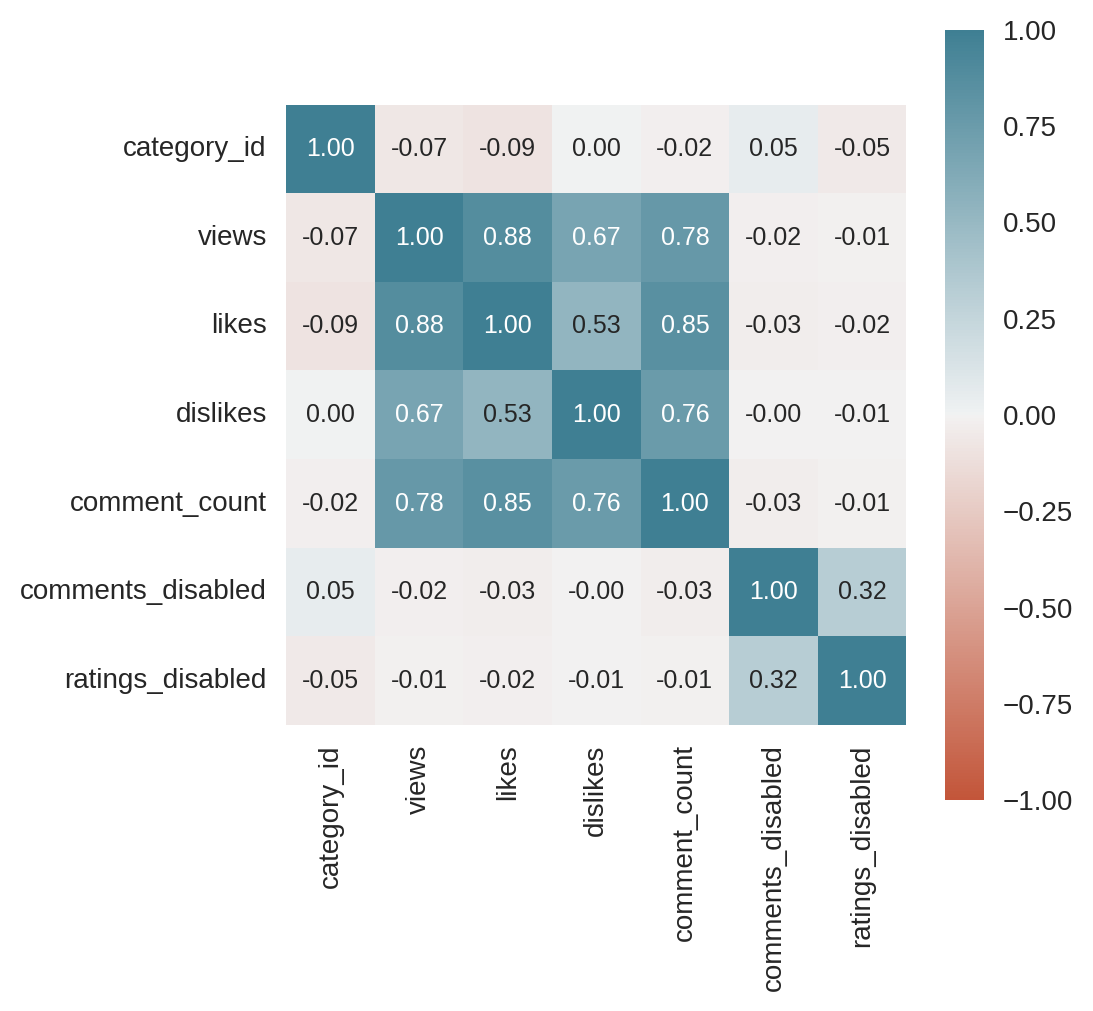

In [ ]:
palette = sns.diverging_palette(20, 220, as_cmap=True)

plt.figure(figsize=(5,5))
sns.heatmap(
    dfYoutube.corr(), square=True, annot=True,
    annot_kws=dict(fontsize=9), fmt='.2f',
    cmap=palette,
    vmin=-1, vmax=1,
)
plt.show()

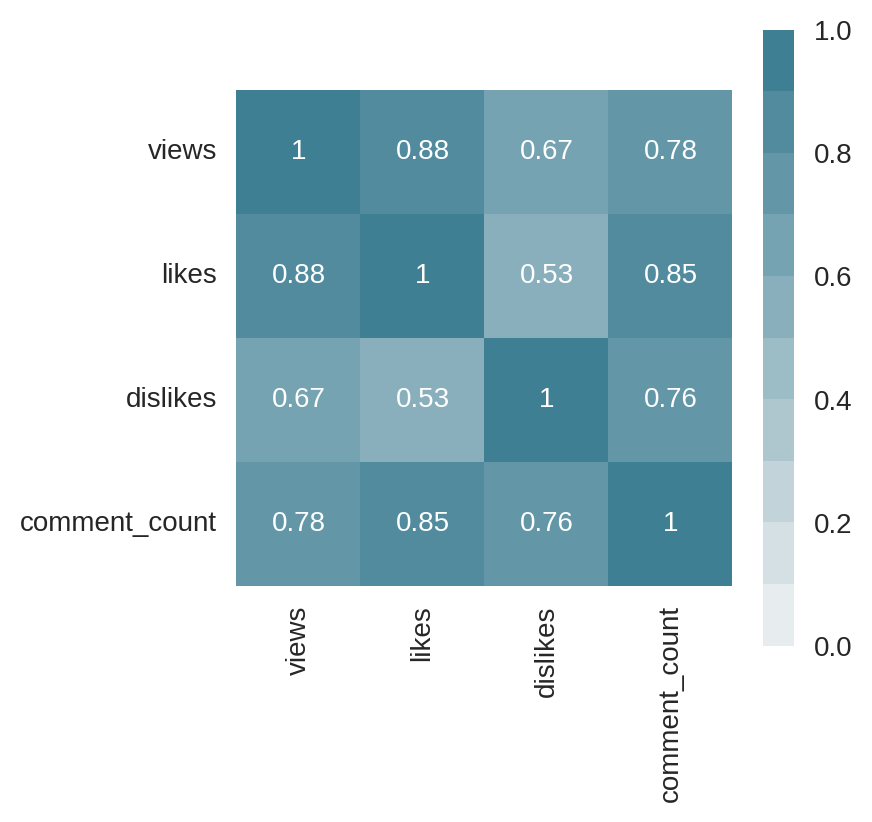

In [ ]:
subset = ['views','likes','dislikes','comment_count']

palette = sns.diverging_palette(20, 220, n=20)[10:]

plt.figure(figsize=(4,4))
sns.heatmap(
    dfYoutube[subset].corr(), square=True, annot=True,
    cmap=palette,
    vmin=0, vmax=1,
)
plt.show()

## 2.3. Histogram
Biểu đồ [Histogram](https://en.wikipedia.org/wiki/Histogram) biểu diễn phân phối của dữ liệu. Nó sẽ đếm số bản ghi xuất hiện trong mỗi bin (mỗi khoảng giá trị) và thể hiện lên mỗi bin là 1 bar, bin nào có nhiều bản ghi sẽ cao hơn các bin còn lại. Lưu ý rằng histogram nhìn khá giống bar chart tuy nhiên chúng truyền tải các thông tin hoàn toàn khác nhau - không nên nhầm lẫn.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use(['seaborn-v0_8', 'seaborn-v0_8-whitegrid'])
%config InlineBackend.figure_format = 'retina'

### Basic Histogram

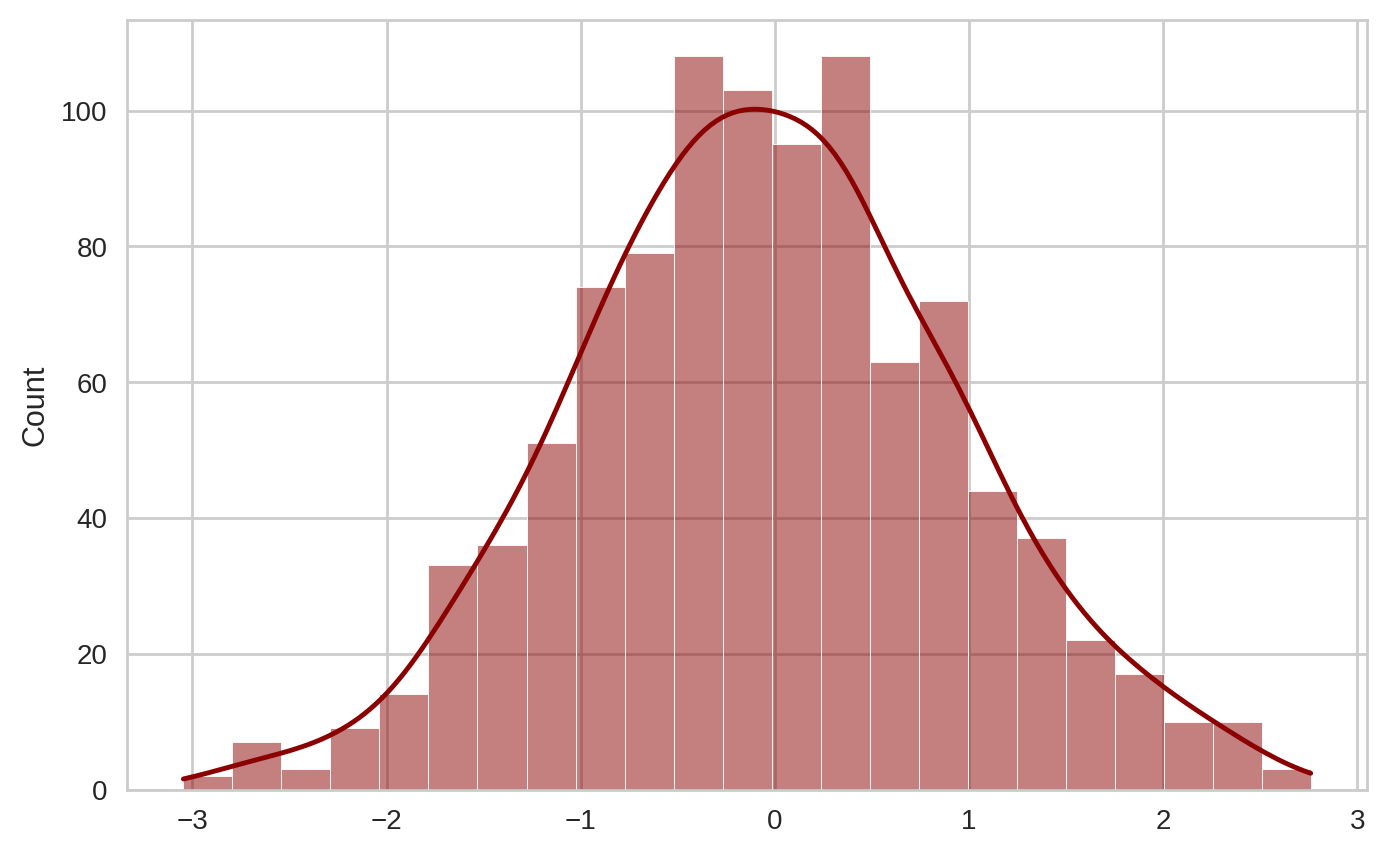

In [ ]:
np.random.seed(0)
x = np.random.normal(size=1000)

plt.figure(figsize=(8,5))
sns.histplot(x, color='darkred', kde=True, stat='count', edgecolor='w')
plt.show()

♈ **Case Study 9**

Vẽ histogram của trường `dislikes` và `likes` trong `youtube_trending`

In [ ]:
import pandas as pd
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")

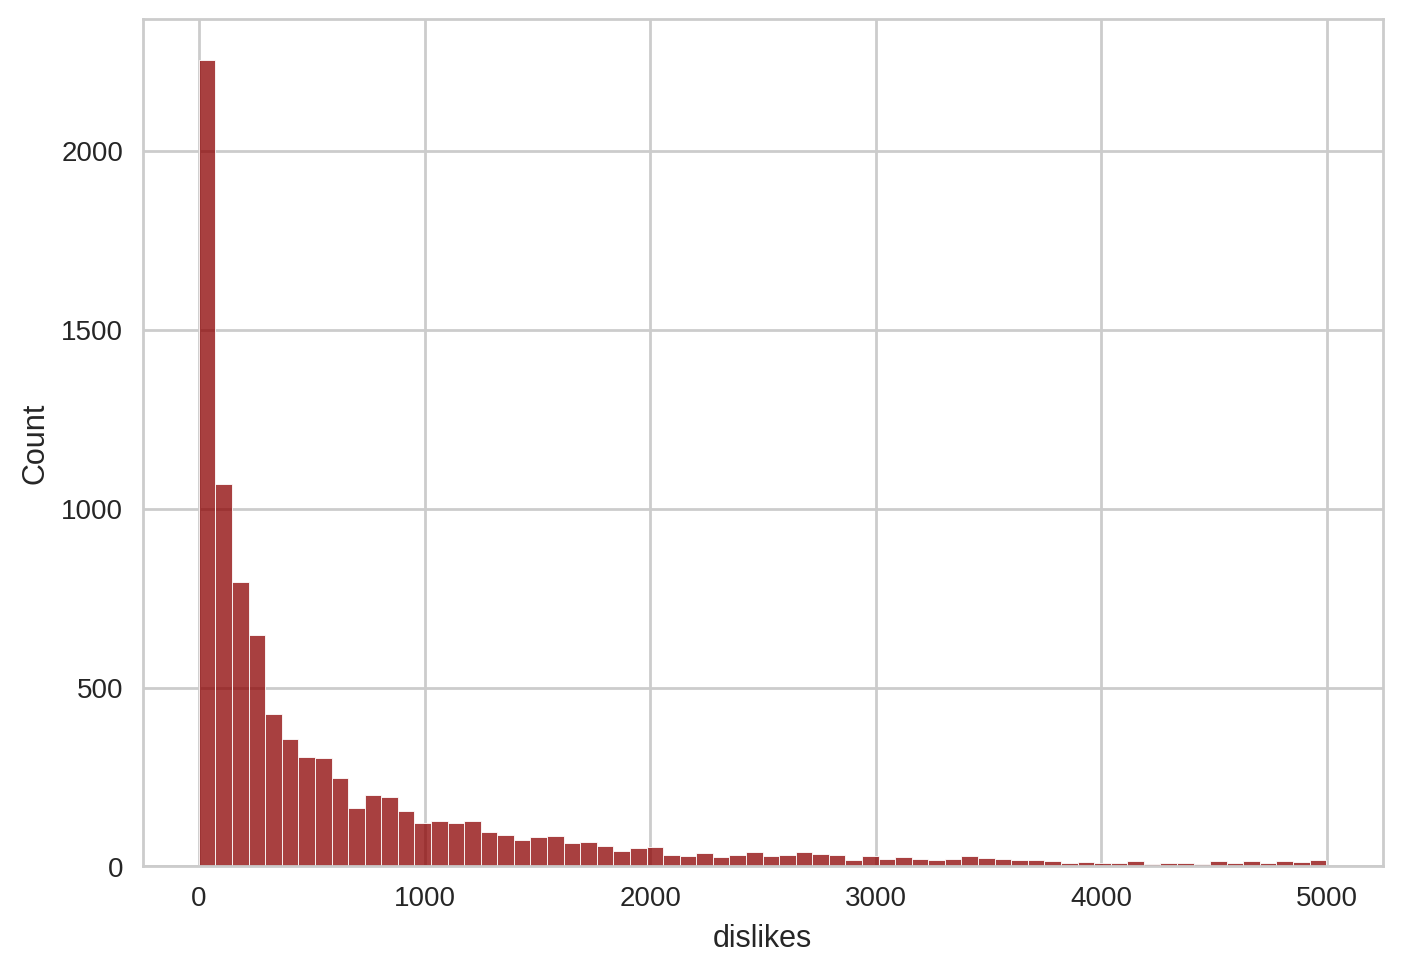

In [ ]:
x = dfYoutube.dislikes
x = x[x < 5000]

sns.histplot(x, color='darkred', stat='count', edgecolor='w')
plt.show()

### Kernel density estimation
Kernel Density Estimation (KDE) là phương pháp ước lượng hàm PDF của một tập dữ liệu. Thường được dùng kèm Histogram.

<br>
<center>
<img src="https://blogs.sas.com/content/iml/files/2016/07/kdecomponents1.png" width=600px;>
</center>

*Nguồn: https://blogs.sas.com/content/iml/2016/07/27/visualize-kernel-density-estimate.html*



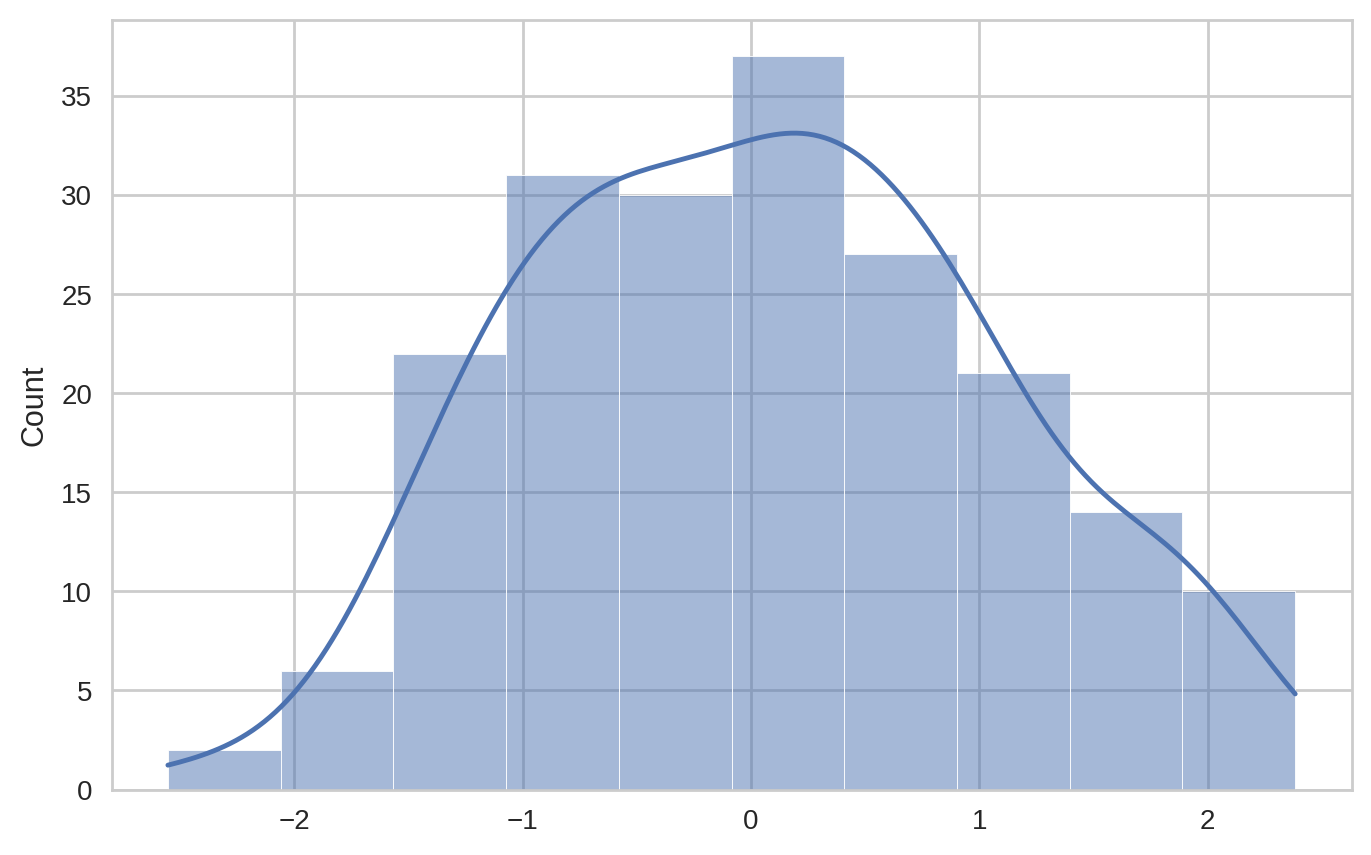

In [ ]:
np.random.seed(0)
x = np.random.normal(size=200)

plt.figure(figsize=(8,5))
sns.histplot(x, kde=True, stat='count', edgecolor='w')
plt.show()

♈ **Case Study 10**

Thực hành lại case study 8, bổ sung KDE

<Axes: xlabel='dislikes', ylabel='Count'>

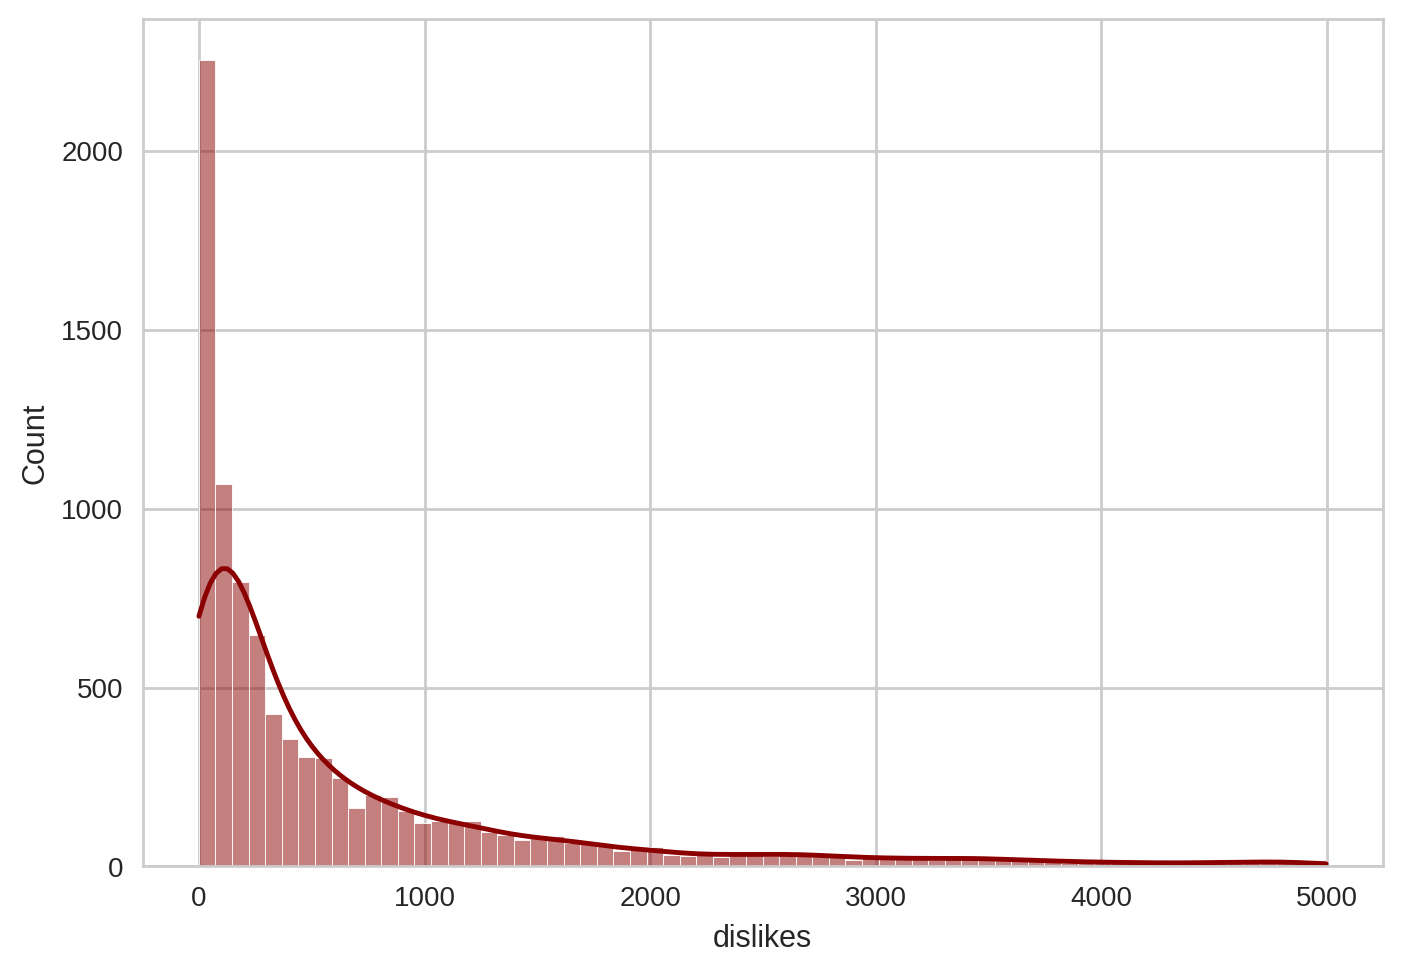

In [ ]:
x = dfYoutube.dislikes
x = x[x < 5000]

sns.histplot(x, color='darkred', kde=True, stat='count', edgecolor='w')

## 2.4. Box Plot
[Box Plots](https://en.wikipedia.org/wiki/Box_plot) cũng sử dụng để biểu diễn phân phối dữ liệu, nó đơn giản hơn histogram nhưngcó thể sử dụng để phát hiện outliers.

Mô tả box plot:
- Chiếc hộp có 3 mốc tương ứng với 3 giá trị phân vị: $Q_1$, $Q_2$, $Q_3$, đường kẻ giữa hộp là giá trị trung vị - $Q2$
- Đường kẻ thấp nhất là giá trị nhỏ hơn trong 2 giá trị $Q_1-1.5\cdot\mbox{IQR}$ và min
- Đường kẻ cao nhất là giá trị lớn hơn trong 2 giá trị $Q_3+1.5\cdot\mbox{IQR}$ và max

Một số insight có thể đọc từ box plot:
- Phát hiện những giá trị outliers: Outlier là điểm nằm ngoài hẳn chiếc râu mèo
- Quan sát độ lệch của phân phối: Chúng ta có thể dễ dàng nhìn thấy phân phối dữ liệu đang lệch trái, lệch phải hay cân bằng bằng cách so sánh $Q_2-Q_1$ và $Q_3-Q_2$.
- Quan sát độ rộng của phân phối: Ria mèo càng xa thì phân phối càng rộng và cách xa điểm trung bình
- So sánh theo categories: Nếu trung vị của 1 nhóm nằm ngoài hộp của nhóm khác, thì có thể nói có sự chênh lệch về phân phối giữa 2 nhóm. VD: Box plot thê hiện phân phối thu nhập của nam và nữ cho thấy thu nhập của nam cao hơn của nữ.

<br>
<center>
<img src="https://api.www.labxchange.org/api/v1/xblocks/lb:LabXchange:d8863c77:html:1/storage/211626365402575-b88c4d0fdacd5abb4c3dc2de3bc004bb.png" width=600px;>
</center>


♈ **Coding Session 11**

Vẽ boxplot cho tập `youtube_trending` biểu diễn phân phối số lượng views của các categories: *Film and Animation (id=1)*, *Comedy (id=23)* và *Sports (id=17)*

In [ ]:
dfYoutube = pd.read_csv("https://raw.githubusercontent.com/hungpq7/course-resource/main/data/youtube_trending.csv")
dfYoutube.head()

,video_id,trending_date,channel_title,category_id,publish_time,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,category_name
0,2kyS6SvSYSE,11/14/2017,CaseyNeistat,22,2017-11-13T17:13:01.000Z,748374,57527,2966,15954,False,False,People & Blogs
1,1ZAPwfrtAFY,11/14/2017,LastWeekTonight,24,2017-11-13T07:30:00.000Z,2418783,97185,6146,12703,False,False,Entertainment
2,5qpjK5DgCt4,11/14/2017,Rudy Mancuso,23,2017-11-12T19:05:24.000Z,3191434,146033,5339,8181,False,False,Comedy
3,puqaWrEC7tY,11/14/2017,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,343168,10172,666,2146,False,False,Entertainment
4,d380meD0W0M,11/14/2017,nigahiga,24,2017-11-12T18:01:41.000Z,2095731,132235,1989,17518,False,False,Entertainment


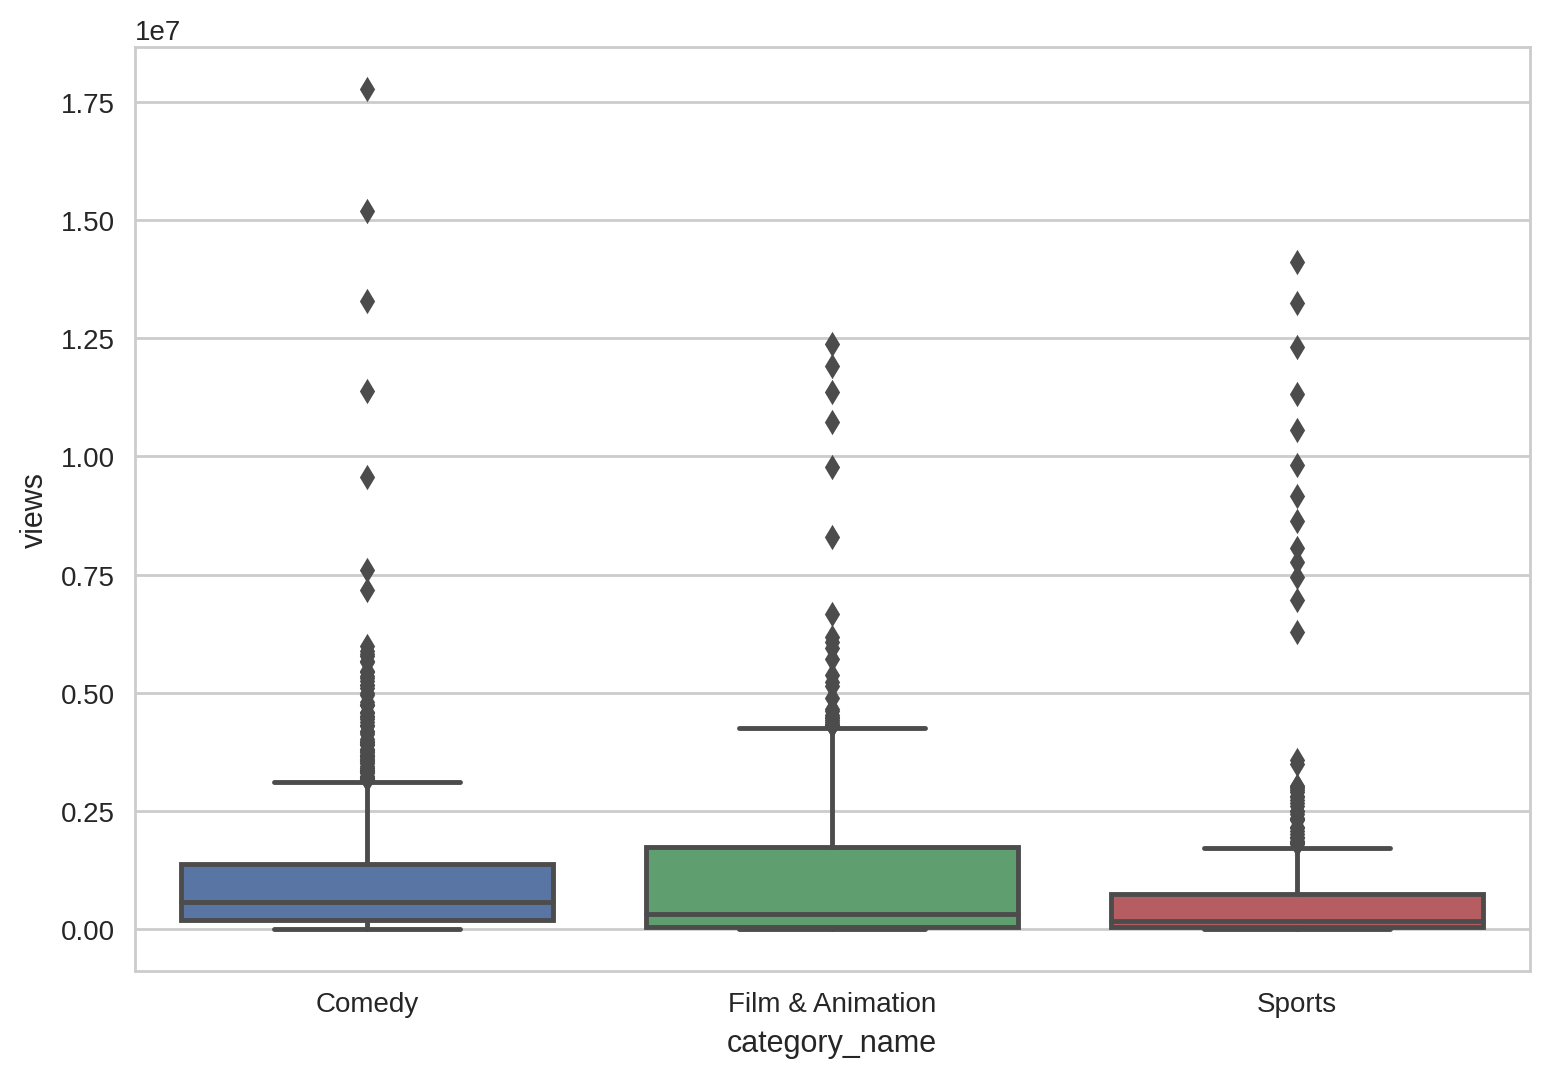

In [ ]:
dfCate = dfYoutube[dfYoutube['category_id'].isin([1,23,17])]

plt.figure(figsize=(9,6))
sns.boxplot(data=dfCate, x='category_name', y='views')
plt.show()

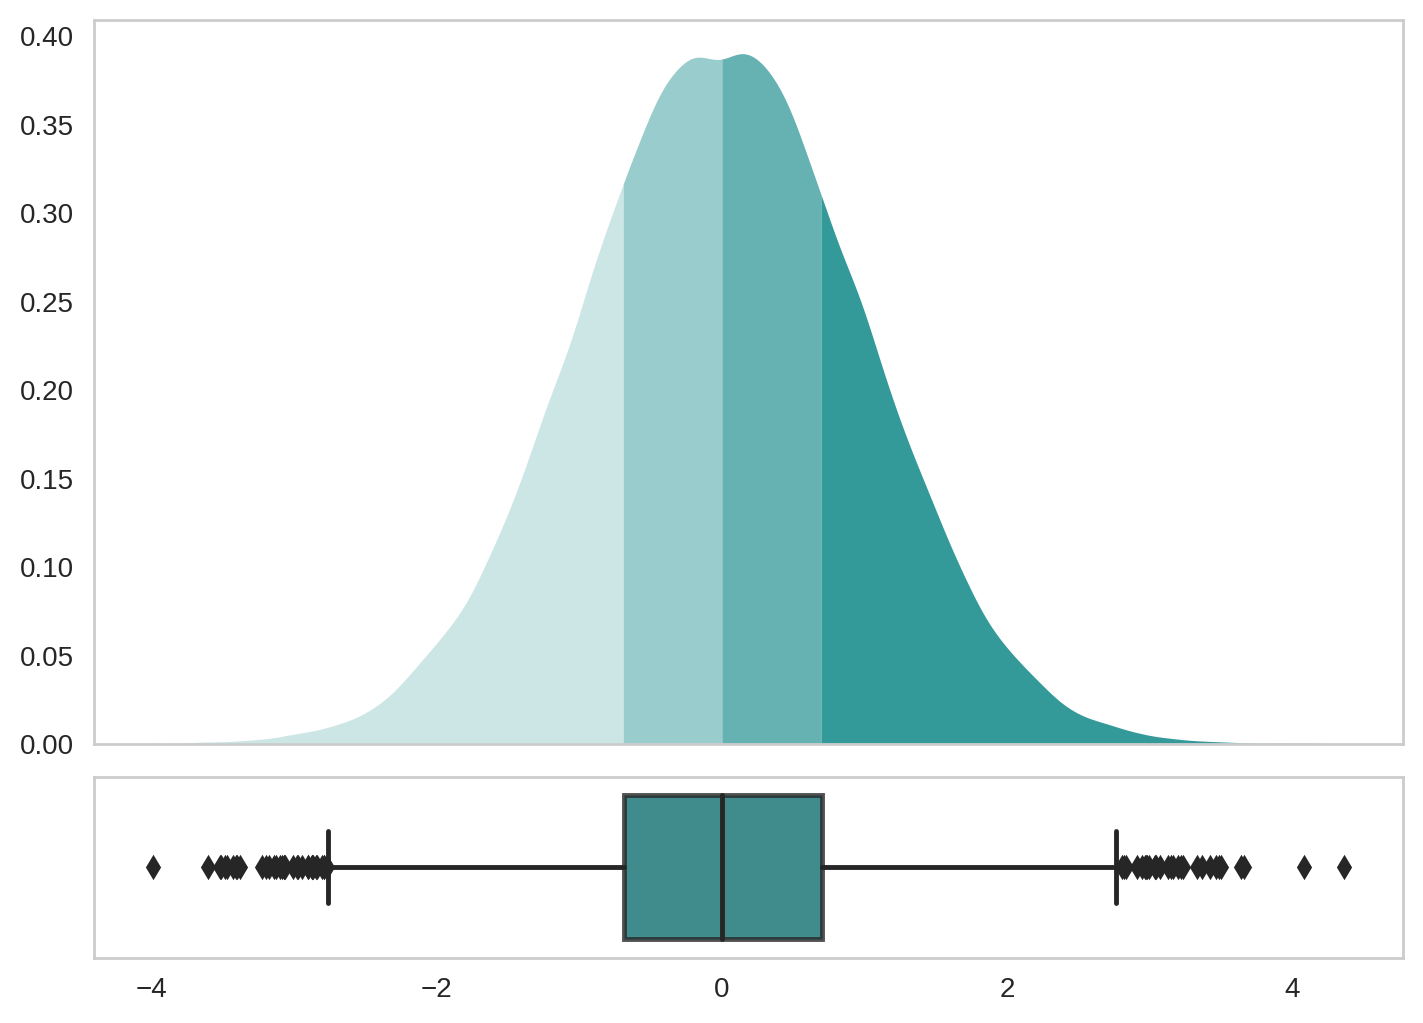

In [ ]:
#@title
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use(['seaborn-v0_8', 'seaborn-v0_8-whitegrid'])
%config InlineBackend.figure_format = 'retina'

sample = stats.norm(loc=0, scale=1).rvs(10000)
q1, q2, q3 = np.quantile(sample, (0.25, 0.5, 0.75))

mosaic = [
    ['kde'],
    ['kde'],
    ['kde'],
    ['kde'],
    ['box'],
]
fig, ax = plt.subplot_mosaic(mosaic, figsize=(7, 5), constrained_layout=True, sharex=True)

xFill = np.linspace(sample.min(), q1, 1000)
yBot = np.zeros(xFill.shape)
yTop = kde(xFill)
ax['kde'].fill_between(xFill, yBot, yTop, color='teal', alpha=0.2, edgecolor=None)

xFill = np.linspace(q1, q2, 1000)
yBot = np.zeros(xFill.shape)
yTop = kde(xFill)
ax['kde'].fill_between(xFill, yBot, yTop, color='teal', alpha=0.4, edgecolor=None)

xFill = np.linspace(q2, q3, 1000)
yBot = np.zeros(xFill.shape)
yTop = kde(xFill)
ax['kde'].fill_between(xFill, yBot, yTop, color='teal', alpha=0.6, edgecolor=None)

xFill = np.linspace(q3, sample.max(), 1000)
yBot = np.zeros(xFill.shape)
yTop = kde(xFill)
ax['kde'].fill_between(xFill, yBot, yTop, color='teal', alpha=0.8, edgecolor=None)

sns.boxplot(x=sample, ax=ax['box'], color='teal', boxprops=dict(alpha=.8))

ax['kde'].set_ylim(bottom=0)
ax['kde'].grid(False)
ax['box'].grid(False)
plt.show()